In [2]:
print('hello world')

hello world


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as ply
import matplotlib.ticker as ticker
from matplotlib.ticker import StrMethodFormatter

In [4]:
df = pd.read_excel('C:/Users/chand/OneDrive/Desktop/cleandata.xlsx')

In [5]:
#extracting month number and name  (month name and month number is already in the dataset but now connected to the order date)
df['Month'] = df['Order Date'].dt.month
df['Month Name'] = df['Order Date'].dt.month_name()

In [6]:
df.head()

,Order ID,Order Date,Customer ID,Product,Category,Price,Quantity,Amount,City,Payment Method,Year,Month,Month Name,Quarter
0,11233,2023-08-27,1729,Laptop,Electronics,60499,1,60499,Mumbai,Credit Card,2023,8,August,3
1,13505,2023-03-23,1054,Laptop,Electronics,60498,4,241992,Mumbai,UPI,2023,3,March,1
2,10707,2023-05-25,1782,Laptop,Electronics,60497,2,120994,Chandigarh,Debit Card,2023,5,May,2
3,11387,2023-08-17,1864,Laptop,Electronics,60497,2,120994,Delhi,Debit Card,2023,8,August,3
4,12300,2023-10-13,1659,Laptop,Electronics,60496,4,241984,Mumbai,Cash on Delivery,2023,10,October,4


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2877 entries, 0 to 2876
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Order ID        2877 non-null   int64         
 1   Order Date      2877 non-null   datetime64[us]
 2   Customer ID     2877 non-null   int64         
 3   Product         2877 non-null   str           
 4   Category        2877 non-null   str           
 5   Price           2877 non-null   int64         
 6   Quantity        2877 non-null   int64         
 7   Amount          2877 non-null   int64         
 8   City            2877 non-null   str           
 9   Payment Method  2877 non-null   str           
 10  Year            2877 non-null   int64         
 11  Month           2877 non-null   int32         
 12  Month Name      2877 non-null   str           
 13  Quarter         2877 non-null   int64         
dtypes: datetime64[us](1), int32(1), int64(7), str(5)
memory usage: 303.

In [8]:
df.describe()

,Order ID,Order Date,Customer ID,Price,Quantity,Amount,Year,Month,Quarter
count,2877.000000,2877,2877.000000,2877.000000,2877.00000,2877.000000,2877.000000,2877.000000,2877.000000
mean,12466.488008,2023-12-28 13:38:21.147028,1499.703511,17907.635036,2.50504,45199.322558,2023.494612,6.472367,2.498783
min,10002.000000,2023-01-01 00:00:00,1000.000000,1003.000000,1.00000,1003.000000,2023.000000,1.000000,1.000000
25%,11199.000000,2023-06-28 00:00:00,1249.000000,2267.000000,2.00000,5244.000000,2023.000000,4.000000,2.000000
50%,12446.000000,2023-12-29 00:00:00,1495.000000,5100.000000,2.00000,14535.000000,2023.000000,7.000000,3.000000
75%,13736.000000,2024-06-29 00:00:00,1748.000000,29768.000000,3.00000,60472.000000,2024.000000,9.000000,3.000000
max,15000.000000,2024-12-31 00:00:00,1999.000000,60499.000000,4.00000,241992.000000,2024.000000,12.000000,4.000000
std,1458.968555,NaN,288.473168,20442.397720,1.10932,60266.579263,0.500058,3.421434,1.112148


In [9]:
# 1.	Overall Business Metrics
# Total Orders
len(df)


2877

In [10]:
# Total Revenue
df['Amount'].sum()

np.int64(130038451)

In [11]:
#Avg Order Value
df['Amount'].mean()

np.float64(45199.32255822037)

In [12]:
# 2.	City-Level Analysis
# Revenue by city
df.groupby('City')['Amount'].sum().sort_values(ascending=True)

City
Chandigarh    20703647
Bangalore     20928367
Delhi         21183351
Shimla        21302610
Jaipur        22117758
Mumbai        23802718
Name: Amount, dtype: int64

In [13]:
# Orders by city
df['City'].value_counts()

City
Mumbai        503
Delhi         485
Jaipur        480
Shimla        477
Bangalore     474
Chandigarh    458
Name: count, dtype: int64

In [14]:
# 3. Product Analysis
# Revenue by Product
df.groupby('Product')['Amount'].sum().sort_values(ascending=False)

Product
Laptop        67100505
Phone         30080008
Tablet        21297886
Watch          5053511
Shoes          2947058
Headphones     2060183
Backpack       1499300
Name: Amount, dtype: int64

In [15]:
# Top 5 Products
df.groupby('Product')['Amount'].sum().nlargest(5)

Product
Laptop    67100505
Phone     30080008
Tablet    21297886
Watch      5053511
Shoes      2947058
Name: Amount, dtype: int64

In [16]:
# 4 Category Analysis
# Revenue by category
df.groupby('Category')['Amount'].sum().sort_values()

Category
Accessories      1499300
Fashion          8000569
Electronics    120538582
Name: Amount, dtype: int64

In [19]:
# Category Contribution %
(df.groupby('Category')['Amount'].sum() / df['Amount'].sum())*100

Category
Accessories     1.152967
Electronics    92.694569
Fashion         6.152464
Name: Amount, dtype: float64

In [ ]:
# 5. Time based analysis
# Monthly Revenue
df.groupby('Month Name')['Amount'].sum().sort_values(ascending=False)

Month Name
July         13007759
May          12218892
June         11644110
November     11381288
April        11280436
February     10789555
August       10547828
March        10403921
October      10185091
January      10003140
December      9367688
September     9208743
Name: Amount, dtype: int64

In [ ]:
# Yearly Revenue
df.groupby('Year')['Amount'].sum().sort_values(ascending=False)

Year
2024    65761222
2023    64277229
Name: Amount, dtype: int64

In [ ]:
# Quartely Revenue
df.groupby('Quarter')['Amount'].sum().sort_values(ascending=False)

Quarter
2    35143438
3    32764330
1    31196616
4    30934067
Name: Amount, dtype: int64

In [ ]:
# 6. Payment Analysis
# Orders by Payment Method
df.groupby('Payment Method')['Order ID'].count()

Payment Method
Cash on Delivery    737
Credit Card         709
Debit Card          728
UPI                 703
Name: Order ID, dtype: int64

In [ ]:
# Revenue by Payment Method
df.groupby('Payment Method')['Amount'].sum().sort_values(ascending=False)

Payment Method
Credit Card         34298238
Debit Card          33819217
Cash on Delivery    31218116
UPI                 30702880
Name: Amount, dtype: int64

In [ ]:
# 7. Customer Analysis
# Orders per Customer (Top 10)
df['Customer ID'].value_counts().head(10)

Customer ID
1719    11
1282    10
1438    10
1270     8
1848     8
1254     8
1657     8
1387     8
1610     8
1662     7
Name: count, dtype: int64

In [ ]:
# Total Spending per Customer (Top 10)
df.groupby('Customer ID')['Amount'].sum().sort_values(ascending=False).head(10)

Customer ID
1505    660968
1555    619547
1432    585704
1213    580868
1485    576235
1719    566755
1949    558026
1638    554642
1209    541674
1208    539486
Name: Amount, dtype: int64

In [ ]:
# Avg Spend per Customer (Top 10)
df.groupby('Customer ID')['Amount'].mean().sort_values(ascending=False).head(10)

Customer ID
1704    241320.0
1316    241260.0
1994    240808.0
1881    239984.0
1772    239672.0
1756    239496.0
1093    239414.0
1622    239348.0
1856    239324.0
1076    239088.0
Name: Amount, dtype: float64

In [ ]:
# 8. Advanced Insights
# City + Product revenue
df.groupby(['City','Product'])['Amount'].sum().sort_values(ascending=False)

City        Product   
Mumbai      Laptop        13613057
Chandigarh  Laptop        10927295
Delhi       Laptop        10868834
Bangalore   Laptop        10738010
Shimla      Laptop        10630481
Jaipur      Laptop        10322828
Bangalore   Phone          6051741
Jaipur      Phone          5611165
Delhi       Phone          4979045
Shimla      Phone          4862057
Chandigarh  Phone          4403424
Jaipur      Tablet         4240891
Mumbai      Phone          4172576
Shimla      Tablet         3964382
Mumbai      Tablet         3727033
Chandigarh  Tablet         3591851
Delhi       Tablet         3384987
Bangalore   Tablet         2388742
Mumbai      Watch          1100763
Jaipur      Watch           960342
Shimla      Watch           833785
Delhi       Watch           819361
Chandigarh  Watch           785146
Bangalore   Shoes           585446
Delhi       Shoes           559249
Bangalore   Watch           554114
Mumbai      Shoes           530259
Shimla      Shoes           4636

In [ ]:
# Correlation (Price, Qty, Amount)                  
df[['Price','Quantity','Amount']].corr()

,Price,Quantity,Amount
Price,1.000000,0.014997,0.865919
Quantity,0.014997,1.000000,0.342901
Amount,0.865919,0.342901,1.000000


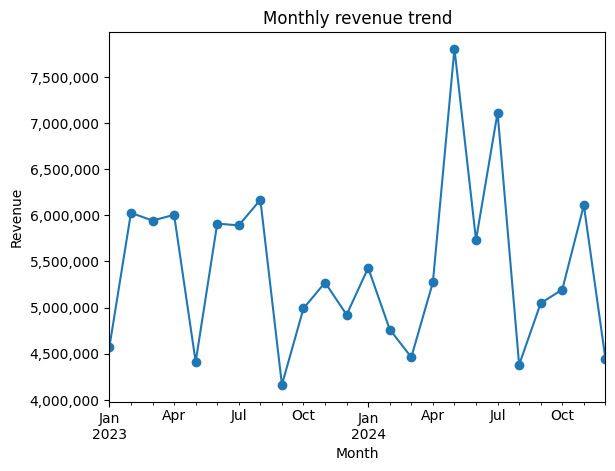

In [ ]:
# 9. VISUALIZATION TABLE
# Monthly Revenue Trend
monthly = df.groupby(df['Order Date'].dt.to_period('M'))['Amount'].sum()

ax = monthly.plot(marker='o')

ax.yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))

ply.title('Monthly revenue trend')
ply.xlabel('Month')
ply.ylabel('Revenue')

ply.show()

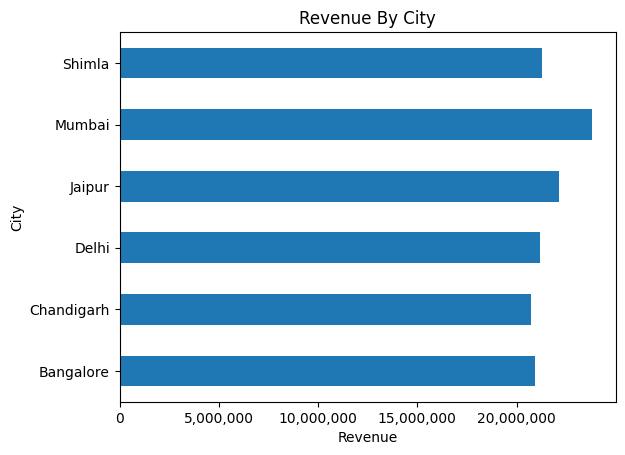

In [ ]:
# Revenue by City 
plottt = df.groupby('City')['Amount'].sum().plot(kind='barh')
plottt.xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

ply.title('Revenue By City')
ply.xlabel('Revenue')
ply.ylabel('City')

ply.show()

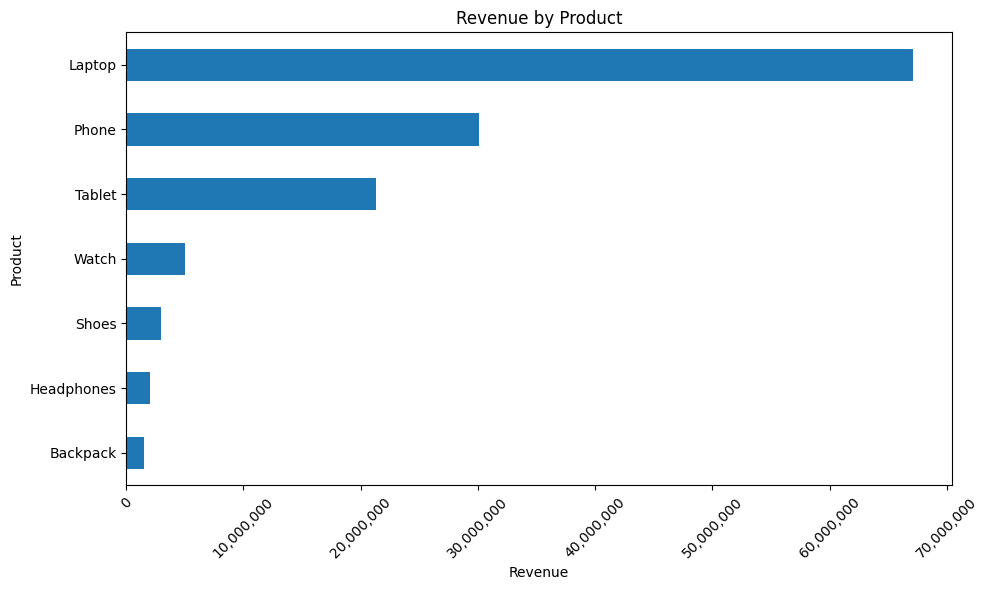

In [ ]:
# Top Products
product_sales =  df.groupby('Product')['Amount'].sum().sort_values()

ply.figure(figsize=(10,6))
tp = product_sales.plot(kind='barh')

tp.xaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))


ply.xticks(rotation=45)
ply.title('Revenue by Product')
ply.xlabel('Revenue')
ply.ylabel('Product')
ply.tight_layout()

ply.show()